In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
import torch
import numpy as np
from matplotlib import pyplot as plt
import math
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import pickle

records = []
with open(f"dynamic_k_save/vit_lora_activations_epochs.pkl", "rb") as f:
    while True:
        try:
            rec = pickle.load(f)
            records.append(rec)
        except EOFError:
            break

In [4]:
num_epochs = len(records)
num_epochs

11

In [5]:
records[0].keys()

dict_keys(['epoch', 'activations'])

In [6]:
records[0]['activations'].keys()

dict_keys(['layer_0.attention', 'layer_0.intermediate', 'layer_1.attention', 'layer_1.intermediate', 'layer_2.attention', 'layer_2.intermediate', 'layer_3.attention', 'layer_3.intermediate', 'layer_4.attention', 'layer_4.intermediate', 'layer_5.attention', 'layer_5.intermediate', 'layer_6.attention', 'layer_6.intermediate', 'layer_7.attention', 'layer_7.intermediate', 'layer_8.attention', 'layer_8.intermediate', 'layer_9.attention', 'layer_9.intermediate', 'layer_10.attention', 'layer_10.intermediate', 'layer_11.attention', 'layer_11.intermediate'])

In [9]:
records[0]['activations']['layer_8.attention']['input'][0].shape

torch.Size([16, 197, 768])

In [ ]:
def rank_need_toget_topx_energy(module_name, x=0.5):
    ranks_across_epochs = []
    for epoch in range(num_epochs):
        ranks = []
        for idx in range(12):
            # io 只有 input
            data = records[epoch]['activations'][f'layer_{idx}.{module_name}']['input'][0].to(torch.float32)
            data = data.reshape(-1, data.shape[-1]).to("cuda")
            singular_values = torch.linalg.svdvals(data)
            cumsum = torch.cumsum(singular_values, dim=0)
            total = cumsum[-1]
            ratio = cumsum / total
            rank = torch.sum(ratio < x).item() + 1
            ranks.append(rank)
        ranks_across_epochs.append(ranks)
    return ranks_across_epochs


In [25]:
attn_input_ranks0p5 = rank_need_toget_topx_energy('attention', 0.5)
mlp_input_ranks0p5 = rank_need_toget_topx_energy('intermediate', 0.5)

In [26]:
attn_input_ranks0p1 = rank_need_toget_topx_energy('attention', 0.1)
mlp_input_ranks0p1 = rank_need_toget_topx_energy('intermediate', 0.1)

In [27]:
attn_input_ranks0p9 = rank_need_toget_topx_energy('attention', 0.9)
mlp_input_ranks0p9 = rank_need_toget_topx_energy('intermediate', 0.9)

In [11]:
attn_input_ranks0p5

[[19, 49, 94, 128, 147, 154, 152, 148, 144, 143, 143, 140],
 [19, 50, 95, 126, 145, 150, 148, 145, 140, 136, 131, 117],
 [19, 50, 97, 127, 146, 151, 149, 146, 140, 136, 132, 116],
 [19, 50, 95, 126, 145, 151, 150, 146, 140, 137, 134, 121],
 [19, 51, 97, 129, 148, 154, 152, 149, 143, 140, 136, 121],
 [19, 50, 96, 128, 147, 154, 152, 149, 144, 141, 137, 123],
 [19, 51, 97, 129, 148, 155, 153, 150, 145, 142, 139, 123],
 [19, 51, 97, 129, 148, 155, 154, 150, 145, 142, 139, 122],
 [19, 51, 97, 129, 149, 155, 154, 151, 145, 142, 139, 121],
 [19, 51, 97, 129, 149, 155, 154, 151, 145, 142, 139, 121],
 [19, 51, 97, 129, 149, 155, 154, 151, 146, 142, 139, 121]]

In [12]:
mlp_input_ranks0p5

[[30, 66, 99, 126, 141, 146, 143, 138, 137, 135, 131, 113],
 [29, 66, 98, 125, 138, 141, 140, 134, 131, 126, 115, 86],
 [29, 67, 100, 126, 139, 143, 141, 135, 131, 127, 116, 84],
 [29, 66, 99, 126, 139, 143, 141, 134, 131, 128, 118, 90],
 [29, 68, 101, 128, 141, 145, 144, 138, 134, 131, 119, 89],
 [29, 67, 101, 128, 141, 145, 144, 138, 135, 131, 120, 90],
 [29, 67, 101, 128, 142, 146, 145, 139, 136, 132, 121, 89],
 [29, 67, 101, 129, 142, 147, 145, 139, 136, 132, 120, 88],
 [29, 67, 101, 129, 142, 147, 145, 139, 136, 133, 120, 87],
 [29, 67, 101, 129, 142, 147, 145, 139, 136, 133, 120, 87],
 [29, 67, 101, 129, 142, 147, 145, 139, 136, 133, 120, 87]]

In [13]:
def plot_rank_across_layers(ranks_across_epochs, title="Attn input rank (top-50% energy)"):
    """
    ranks_across_epochs: list[num_epochs][num_layers]
        例如 attn_input_ranks0p5
    """
    num_epochs = len(ranks_across_epochs)
    if num_epochs == 0:
        print("ranks_across_epochs 为空")
        return

    num_layers = len(ranks_across_epochs[0])
    layer_idx = np.arange(num_layers)

    plt.figure(figsize=(8, 5))

    for epoch in range(num_epochs):
        ranks = ranks_across_epochs[epoch]
        plt.plot(
            layer_idx,
            ranks,
            marker="o",
            label=f"epoch {epoch}",
            alpha=0.7,
        )

    plt.xlabel("Layer index")
    plt.ylabel("Rank")
    plt.title(title)
    plt.xticks(layer_idx)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

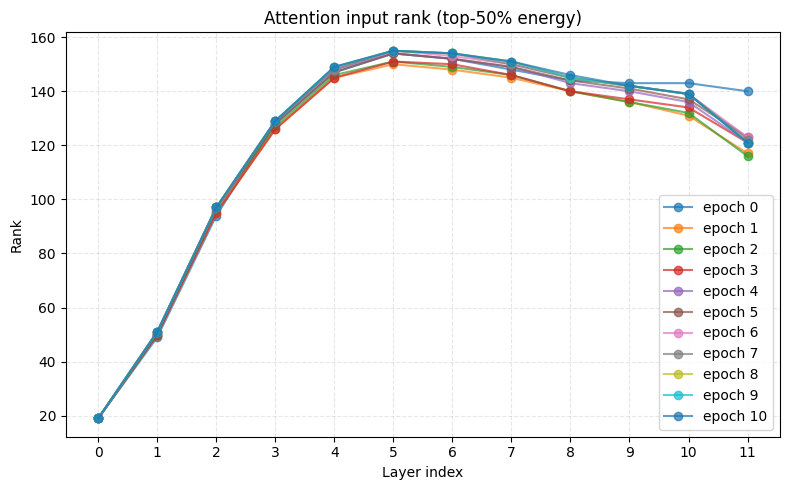

In [14]:
plot_rank_across_layers(attn_input_ranks0p5, title="Attention input rank (top-50% energy)")

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rank_across_epochs(ranks_across_epochs, title="Attn input rank (top-50% energy)"):
    """
    ranks_across_epochs: list[num_epochs][num_layers]
        例如 attn_input_ranks0p5
    """
    num_epochs = len(ranks_across_epochs)
    if num_epochs == 0:
        print("ranks_across_epochs 为空")
        return

    num_layers = len(ranks_across_epochs[0])
    epoch_idx = np.arange(num_epochs)

    plt.figure(figsize=(8, 5))

    # 每条线代表一个 layer
    for layer in range(num_layers):
        ranks = [ranks_across_epochs[epoch][layer] for epoch in range(num_epochs)]
        print(ranks)
        plt.plot(
            epoch_idx,
            ranks,
            marker="o",
            label=f"Layer {layer}",
            alpha=0.7,
        )

    plt.xlabel("Epoch")
    plt.ylabel("Rank")
    plt.title(title)
    plt.xticks(epoch_idx)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend(title="Layer", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
[9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9]
[12, 11, 12, 11, 12, 12, 12, 12, 12, 12, 12]
[14, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14]
[15, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14]
[14, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14]
[13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14]
[13, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13]
[12, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11]
[11, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10]
[10, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8]


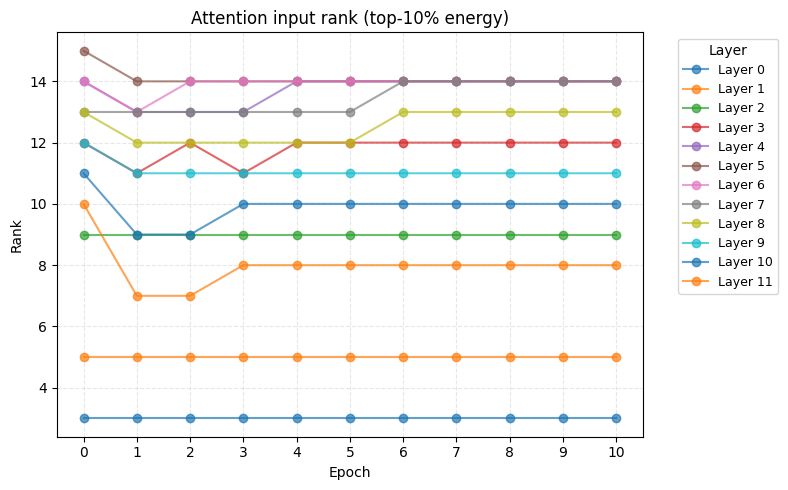

In [19]:
plot_rank_across_epochs(attn_input_ranks0p1, title="Attention input rank (top-10% energy)")

[19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19]
[49, 50, 50, 50, 51, 50, 51, 51, 51, 51, 51]
[94, 95, 97, 95, 97, 96, 97, 97, 97, 97, 97]
[128, 126, 127, 126, 129, 128, 129, 129, 129, 129, 129]
[147, 145, 146, 145, 148, 147, 148, 148, 149, 149, 149]
[154, 150, 151, 151, 154, 154, 155, 155, 155, 155, 155]
[152, 148, 149, 150, 152, 152, 153, 154, 154, 154, 154]
[148, 145, 146, 146, 149, 149, 150, 150, 151, 151, 151]
[144, 140, 140, 140, 143, 144, 145, 145, 145, 145, 146]
[143, 136, 136, 137, 140, 141, 142, 142, 142, 142, 142]
[143, 131, 132, 134, 136, 137, 139, 139, 139, 139, 139]
[140, 117, 116, 121, 121, 123, 123, 122, 121, 121, 121]


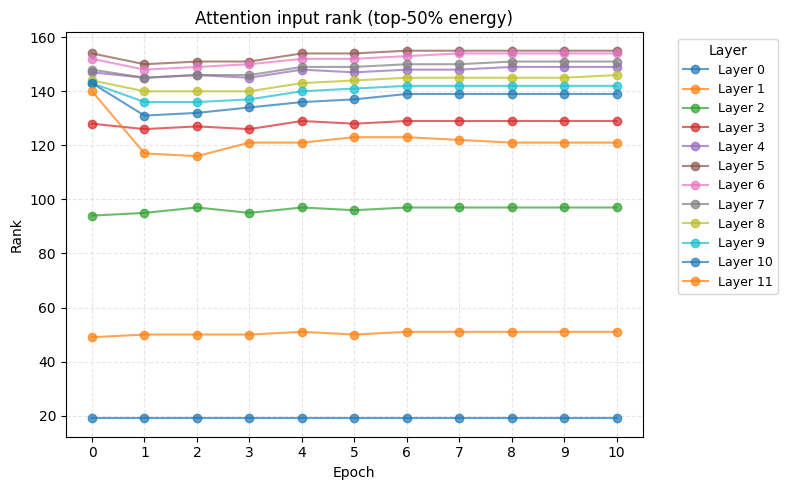

In [18]:
plot_rank_across_epochs(attn_input_ranks0p5, title="Attention input rank (top-50% energy)")

[139, 138, 138, 138, 138, 138, 138, 138, 138, 138, 138]
[307, 310, 313, 310, 312, 311, 311, 311, 311, 311, 311]
[415, 418, 421, 419, 421, 420, 421, 421, 421, 421, 421]
[481, 480, 483, 481, 484, 484, 484, 485, 485, 485, 485]
[514, 513, 515, 514, 517, 516, 517, 517, 517, 517, 517]
[534, 530, 531, 531, 534, 534, 535, 535, 536, 536, 536]
[538, 535, 537, 536, 540, 540, 541, 541, 541, 541, 541]
[540, 536, 538, 538, 541, 541, 542, 543, 543, 543, 543]
[541, 537, 538, 538, 541, 542, 543, 543, 543, 543, 543]
[544, 537, 538, 538, 541, 542, 544, 544, 544, 544, 544]
[547, 537, 538, 539, 542, 543, 544, 544, 544, 545, 544]
[543, 526, 526, 529, 530, 533, 533, 532, 532, 532, 532]


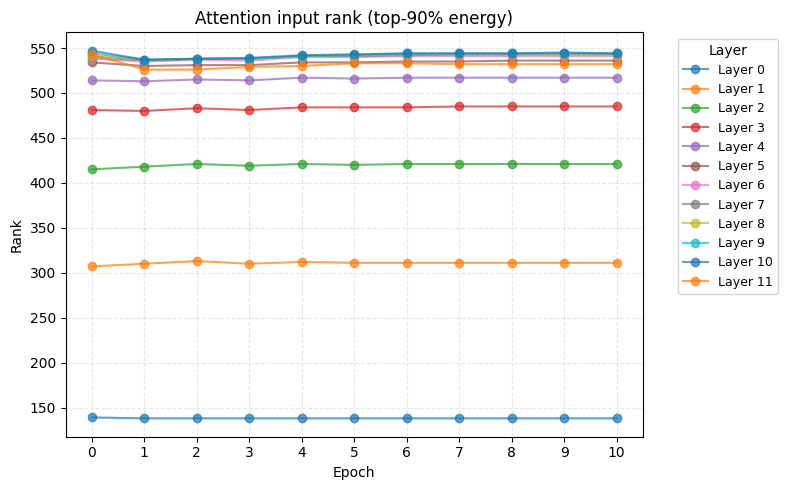

In [20]:
plot_rank_across_epochs(attn_input_ranks0p9, title="Attention input rank (top-90% energy)")

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
[7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
[10, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10]
[11, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11]
[12, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12]
[12, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12]
[11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11]
[11, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11]
[10, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10]
[9, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
[6, 4, 4, 5, 5, 5, 5, 4, 4, 4, 4]


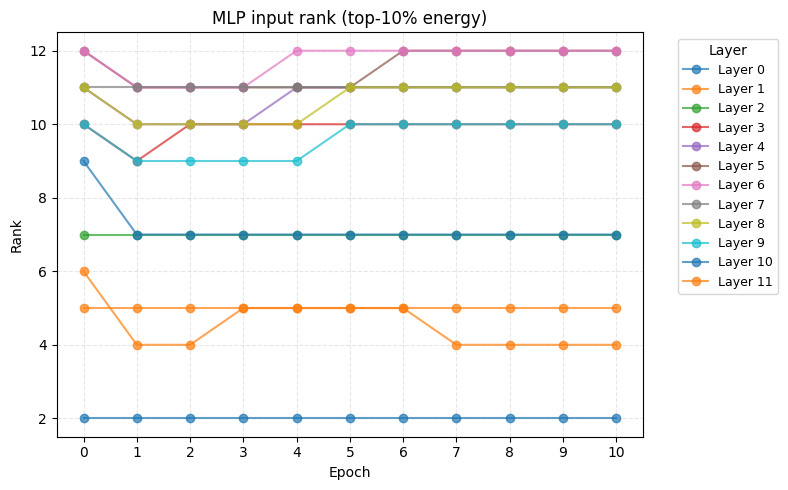

In [21]:
plot_rank_across_epochs(mlp_input_ranks0p1, title="MLP input rank (top-10% energy)")

[30, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29]
[66, 66, 67, 66, 68, 67, 67, 67, 67, 67, 67]
[99, 98, 100, 99, 101, 101, 101, 101, 101, 101, 101]
[126, 125, 126, 126, 128, 128, 128, 129, 129, 129, 129]
[141, 138, 139, 139, 141, 141, 142, 142, 142, 142, 142]
[146, 141, 143, 143, 145, 145, 146, 147, 147, 147, 147]
[143, 140, 141, 141, 144, 144, 145, 145, 145, 145, 145]
[138, 134, 135, 134, 138, 138, 139, 139, 139, 139, 139]
[137, 131, 131, 131, 134, 135, 136, 136, 136, 136, 136]
[135, 126, 127, 128, 131, 131, 132, 132, 133, 133, 133]
[131, 115, 116, 118, 119, 120, 121, 120, 120, 120, 120]
[113, 86, 84, 90, 89, 90, 89, 88, 87, 87, 87]


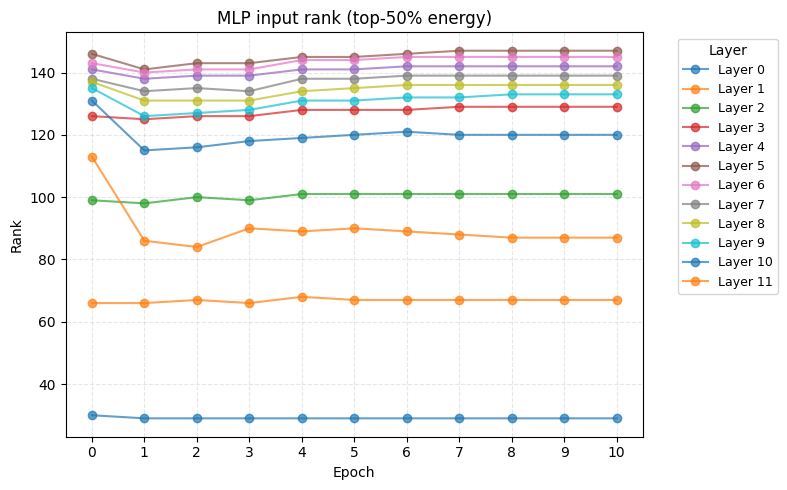

In [22]:
plot_rank_across_epochs(mlp_input_ranks0p5, title="MLP input rank (top-50% energy)")

[197, 195, 196, 193, 194, 195, 194, 195, 195, 195, 195]
[339, 342, 344, 344, 346, 344, 345, 345, 345, 345, 345]
[431, 433, 437, 435, 438, 437, 437, 438, 438, 438, 438]
[489, 489, 492, 491, 494, 494, 494, 494, 495, 495, 495]
[520, 518, 520, 520, 522, 522, 523, 524, 524, 524, 524]
[532, 529, 531, 530, 533, 534, 535, 535, 535, 535, 535]
[535, 532, 534, 533, 537, 537, 538, 538, 538, 538, 538]
[534, 530, 531, 530, 534, 535, 536, 536, 536, 537, 537]
[536, 531, 532, 531, 535, 536, 537, 537, 537, 537, 537]
[539, 530, 532, 532, 535, 536, 537, 538, 538, 538, 538]
[540, 526, 527, 528, 531, 532, 533, 533, 532, 533, 532]
[528, 505, 503, 509, 509, 511, 510, 509, 509, 508, 508]


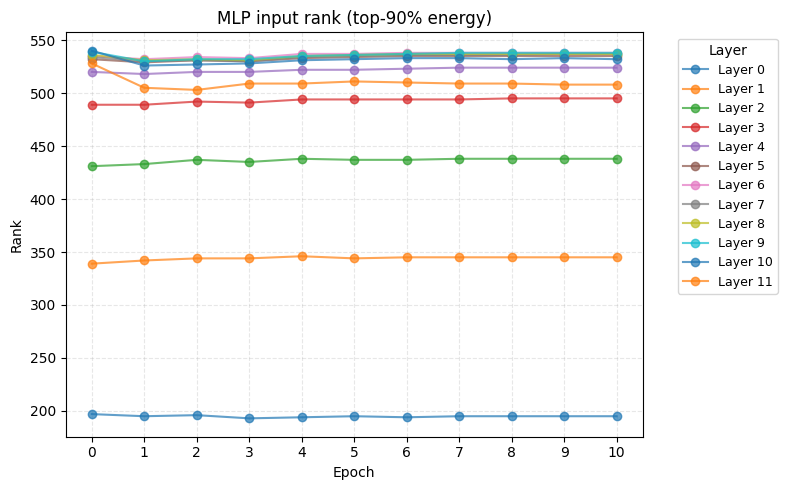

In [23]:
plot_rank_across_epochs(mlp_input_ranks0p9, title="MLP input rank (top-90% energy)")

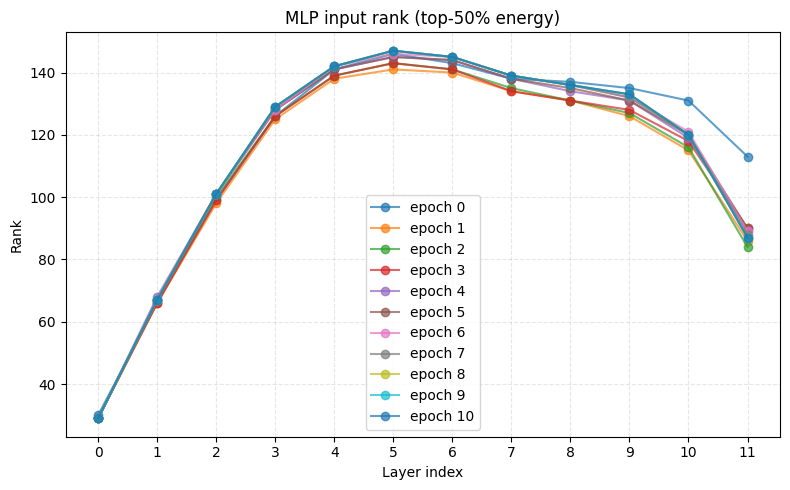

In [12]:
plot_rank_across_layers(mlp_input_ranks0p5, title="MLP input rank (top-50% energy)")

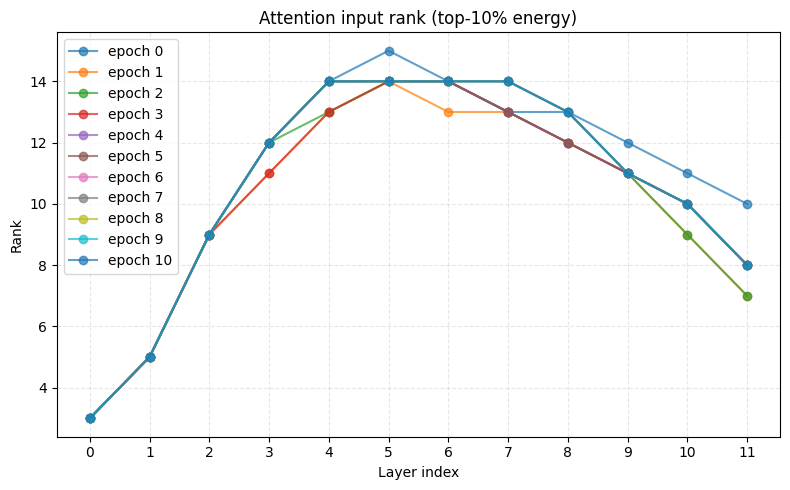

In [13]:
plot_rank_across_layers(attn_input_ranks0p1, title="Attention input rank (top-10% energy)")

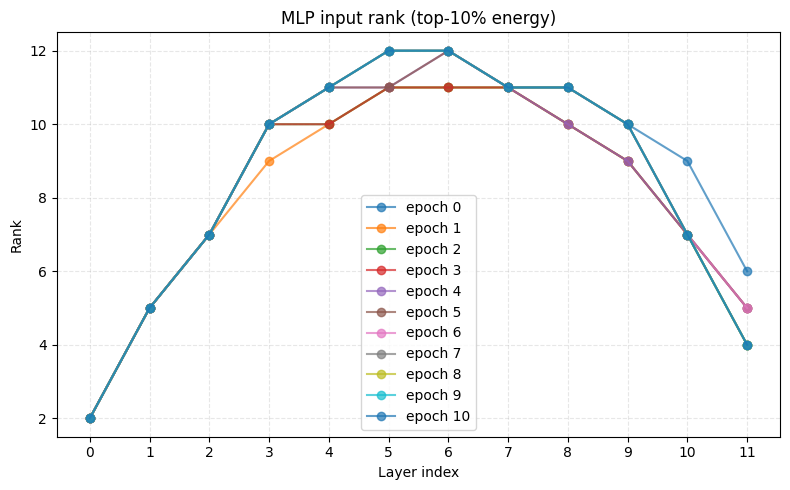

In [14]:
plot_rank_across_layers(mlp_input_ranks0p1, title="MLP input rank (top-10% energy)")

In [74]:
def get_topk_singular_vectors(module_name, k=10):
    V_across_epochs = []

    for epoch in range(num_epochs):
        V_layers = {}

        for idx in range(12):  # 12 个 layer
            # 取激活: [B, ..., D]
            data = records[epoch]['activations'][f'layer_{idx}.{module_name}']['input'][0].to(torch.float32)
            data = data.reshape(-1, data.shape[-1]).to("cuda")  # [N, D]

            # SVD
            # data = U @ diag(S) @ Vh
            U, S, Vh = torch.linalg.svd(data, full_matrices=False)
            # 取前 k 个
            V_kT = Vh[:k, :]             # [k, D]，右奇异向量的转置

            V_layers[idx] = V_kT.cpu()

        V_across_epochs.append(V_layers)

    return V_across_epochs

In [118]:
attn_input_singular_vectors_top48 = get_topk_singular_vectors('attention', k=48)
mlp_input_singular_vectors_top48 = get_topk_singular_vectors('intermediate', k=48)

In [119]:
len(attn_input_singular_vectors_top48)

11

In [120]:
attn_input_singular_vectors_top48[0].keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])

In [121]:
attn_input_singular_vectors_top48[0][0].shape

torch.Size([48, 768])

In [94]:
import numpy as np

def compute_topx_subspace_similarity_epoch0based(V_list, topx=3):
    num_epochs = len(V_list)
    num_layers = len(V_list[0])

    sim = np.zeros((num_epochs-1, num_layers), dtype=np.float32)

    for layer in range(num_layers):
        # epoch 0 的 top‑x 奇异向量 [topx, D]
        V0 = V_list[0][layer][:topx].clone()  # 防止原地改
        V0 = V0 / (V0.norm(dim=1, keepdim=True) + 1e-12)

        for epoch in range(1, num_epochs):
            V = V_list[epoch][layer][:topx].clone()
            V = V / (V.norm(dim=1, keepdim=True) + 1e-12)

            # V, V0: [topx, D]
            # M: [topx, topx]，每个元素是奇异向量之间的 cos
            M = V @ V0.T
            # 平均 cos^2 作为子空间相似度
            val = (M ** 2).sum().item() / float(topx)
            sim[epoch-1, layer] = val

    return sim

In [108]:
def plot_similarity_heatmap(sim, title="Principal vector similarity (vs epoch 0)"):
    """
    sim: np.ndarray[num_epochs, num_layers]
    """
    plt.figure(figsize=(8, 4))
    im = plt.imshow(sim, aspect="auto", cmap="viridis", origin="lower")
    plt.colorbar(im, label="cosine similarity")
    plt.xlabel("Layer index")
    plt.ylabel("Epoch")
    plt.title(title)
    plt.xticks(np.arange(sim.shape[1]))
    plt.yticks(np.arange(sim.shape[0]))

    # 在每个格子上标注数值
    num_epochs, num_layers = sim.shape
    for i in range(num_epochs):
        for j in range(num_layers):
            value = sim[i, j]
            plt.text(
                j, i,
                f"{value:.2f}",           # 保留两位小数
                ha="center",
                va="center",
                color="white" if value < 0.5 else "black",  # 简单根据背景深浅换颜色
                fontsize=6,
            )

    plt.tight_layout()
    plt.show()

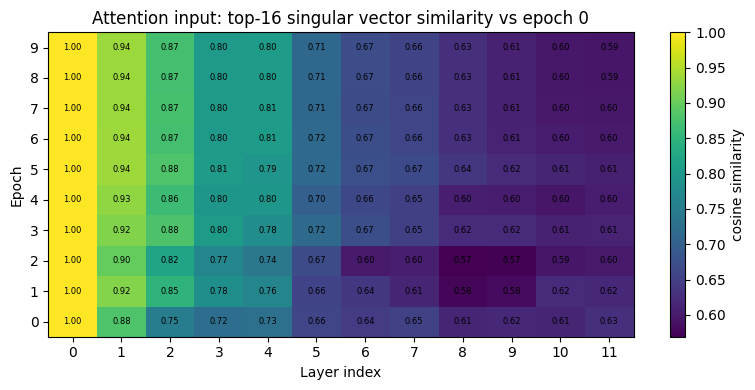

In [ ]:
sim_attn_v0 = compute_topx_subspace_similarity_epoch0based(attn_input_singular_vectors_top48, topx=16)
plot_similarity_heatmap(sim_attn_v0, title="Attention input: top-16 singular vector similarity vs epoch 0")

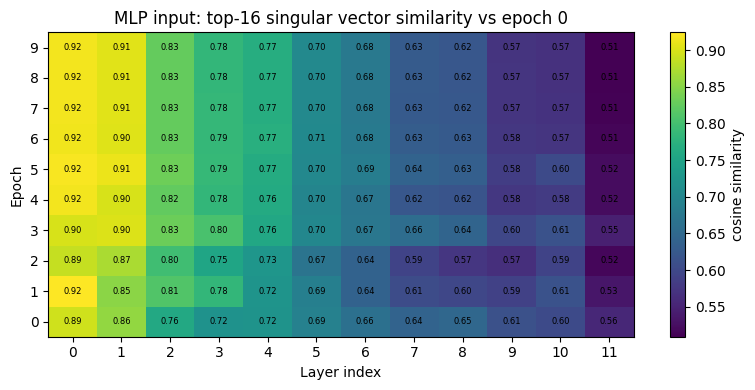

In [122]:
sim_mlp_v0 = compute_topx_subspace_similarity_epoch0based(mlp_input_singular_vectors_top48, topx=16)
plot_similarity_heatmap(sim_mlp_v0, title="MLP input: top-16 singular vector similarity vs epoch 0")

In [111]:
def compute_topx_subspace_similarity_consecutive(V_list, topx=3):
    """
    V_list: list[num_epochs][num_layers]，每个元素是 [k, D] 的 tensor（k >= topx）

    返回:
      sim: np.ndarray[num_epochs-1, num_layers]
           sim[e-1, l] = epoch e vs epoch e-1 在 layer l 的 top‑x 子空间相似度
    """
    num_epochs = len(V_list)
    num_layers = len(V_list[0])

    sim = np.zeros((num_epochs-1, num_layers), dtype=np.float32)

    for layer in range(num_layers):
        for epoch in range(1, num_epochs):
            # 上一个 epoch 的 top‑x 向量
            V_prev = V_list[epoch-1][layer][:topx].clone()
            V_prev = V_prev / (V_prev.norm(dim=1, keepdim=True) + 1e-12)

            # 当前 epoch 的 top‑x 向量
            V_cur = V_list[epoch][layer][:topx].clone()
            V_cur = V_cur / (V_cur.norm(dim=1, keepdim=True) + 1e-12)

            # V_cur, V_prev: [topx, D]
            M = V_cur @ V_prev.T          # [topx, topx]，成对 cos
            val = (M ** 2).sum().item() / float(topx)  # 平均 cos^2
            sim[epoch-1, layer] = val

    return sim

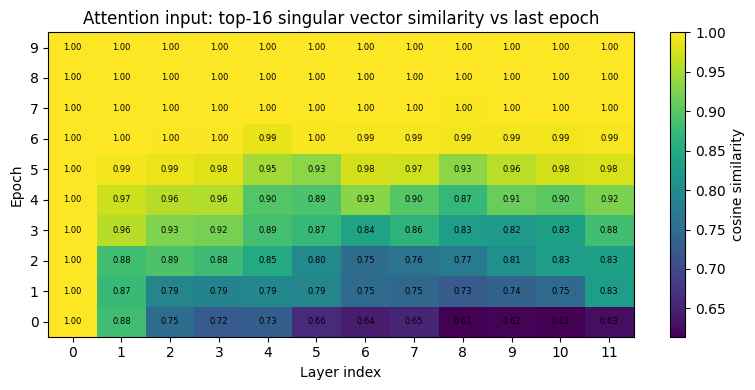

In [123]:
sim_attn_vlast = compute_topx_subspace_similarity_consecutive(attn_input_singular_vectors_top48, topx=16)
plot_similarity_heatmap(sim_attn_vlast, title="Attention input: top-16 singular vector similarity vs last epoch")

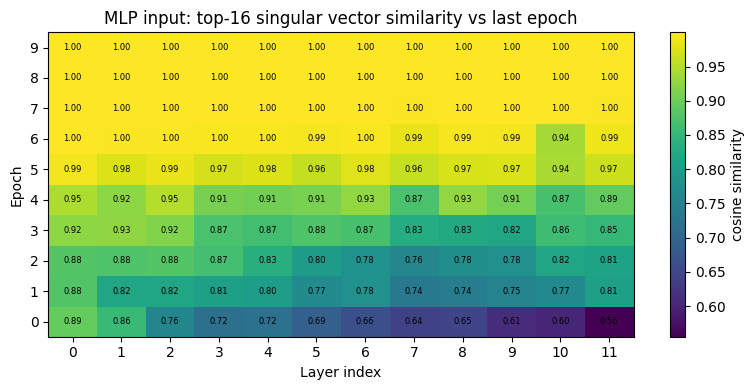

In [124]:
sim_mlp_vlast = compute_topx_subspace_similarity_consecutive(mlp_input_singular_vectors_top48, topx=16)
plot_similarity_heatmap(sim_mlp_vlast, title="MLP input: top-16 singular vector similarity vs last epoch")

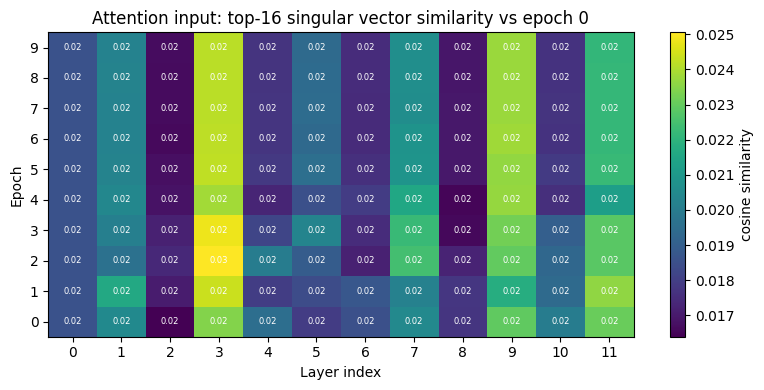

In [125]:
import copy

attn_input_singular_vectors_random = copy.deepcopy(attn_input_singular_vectors_top48)
# 把 epoch 0 替换为从正太分布随机采样
attn_input_singular_vectors_random[0] = {}
for layer in range(12):
    D = attn_input_singular_vectors_top48[1][layer].shape[1]
    random_vectors = torch.randn(48, D)
    attn_input_singular_vectors_random[0][layer] = random_vectors

sim_attn_random_v0 = compute_topx_subspace_similarity_epoch0based(attn_input_singular_vectors_random, topx=16)
plot_similarity_heatmap(sim_attn_random_v0, title="Attention input: top-16 singular vector similarity vs epoch 0")

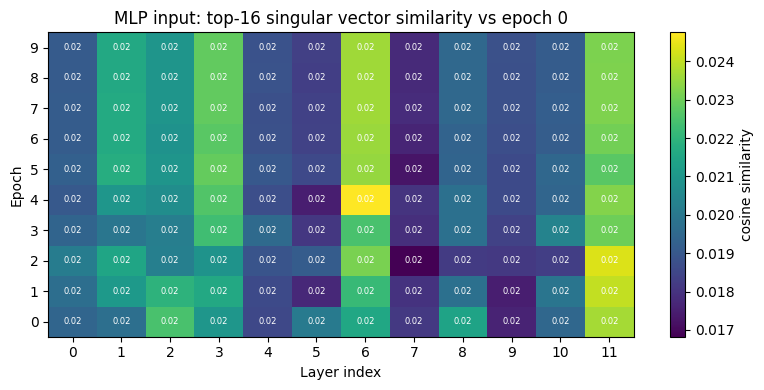

In [126]:
import copy

mlp_input_singular_vectors_random = copy.deepcopy(mlp_input_singular_vectors_top48)
# 把 epoch 0 替换为从正太分布随机采样
mlp_input_singular_vectors_random[0] = {}
for layer in range(12):
    D = mlp_input_singular_vectors_top48[1][layer].shape[1]
    random_vectors = torch.randn(48, D)
    mlp_input_singular_vectors_random[0][layer] = random_vectors

sim_mlp_random_v0 = compute_topx_subspace_similarity_epoch0based(mlp_input_singular_vectors_random, topx=16)
plot_similarity_heatmap(sim_mlp_random_v0, title="MLP input: top-16 singular vector similarity vs epoch 0")